#KNN (K-Nearest Neighbors)

KNN es un algoritmo de aprendizaje automático supervisado que se utiliza para tareas de clasificación y regresión. Funciona buscando los K vecinos más cercanos a un punto de datos determinado en función de una métrica de distancia como la distancia euclidiana. El algoritmo asigna el punto de datos a la clase que es más común entre sus K vecinos más cercanos.

In [ ]:
# Instalar librerías necesarias (Solo ejecutar si no están instaladas)
from IPython.utils import io
import tqdm.notebook

total = 100
with tqdm.notebook.tqdm(total=total) as pbar:
    with io.capture_output() as captured:
        # Instalar rdkit
        !pip -q install rdkit.pypi==2021.9.4
        pbar.update(20)
        # Instalar Pillow
        !pip -q install Pillow
        pbar.update(40)
        # Instalar molplotly
        !pip install molplotly
        pbar.update(60)
        # Instalar jupyter-dash
        !pip install jupyter-dash
        pbar.update(80)
        # Instalar el diseño de aplicación dash
        !pip install dash-bootstrap-components
        pbar.update(100)


  0%|          | 0/100 [00:00<?, ?it/s]

In [ ]:
# Importar librerías
import pandas as pd
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.decomposition import PCA
import seaborn as sns

In [ ]:
# Leer bases de datos
datos = "/content/drive/MyDrive/Doctorado_Santiago/Set de Datos 2/Objetivo 4/0_DATA/Concatenadas_csv.csv"
datos = pd.read_csv(datos)

In [ ]:
datos

,Name,SMILE,Total Molweight,Monoisotopic Mass,cLogP,cLogS,H-Acceptors,H-Donors,Total Surface Area,Relative PSA,...,Hetero-Aromatic Rings,Amides,Amines,Alkyl-Amines,Aromatic Amines,Aromatic Nitrogens,Basic Nitrogens,Acidic Oxygens,DataBase,Senotherapeutic
0,Ferric nitrilotriacetate,C(C(=O)[O-])N(CC(=O)[O-])CC(=O)[O-].[Fe+3],243.960,191.042989,-3.8594,0.868,7,3,137.38,0.59667,...,0,0,1,1,0,0,1,3,NoSenotherapeutic,0
1,Nitrilotriacetic acid,C(C(=O)O)N(CC(=O)O)CC(=O)O,191.138,191.042989,-3.8594,0.868,7,3,137.38,0.59667,...,0,0,1,1,0,0,1,3,NoSenotherapeutic,0
2,Oleuropein aglycone,C/C=C/1\[C@@H](C(=CO[C@H]1O)C(=O)OC)CC(=O)OCCC...,378.376,378.131470,1.5247,-2.068,8,3,284.53,0.33522,...,0,0,0,0,0,0,0,0,Senotherapeutic,1
3,Rapamycin,C[C@@H]1CC[C@H]2C[C@@H](/C(=C/C=C/C=C/[C@H](C[...,914.182,913.555144,6.5106,-6.713,14,3,716.91,0.22046,...,0,1,0,0,0,0,0,0,Senotherapeutic,1
4,KU-60019,C[C@@H]1CN(C[C@@H](O1)C)CC(=O)NC2=CC3=C(C=C2)S...,547.674,547.214092,4.2047,-5.834,8,1,403.09,0.22856,...,0,1,1,1,0,0,1,0,Senotherapeutic,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99,TICRYNAFEN,O=C(O)COc1ccc(C(=O)c2cccs2)c(Cl)c1Cl,331.175,329.952034,2.9282,-4.991,4,1,225.41,0.30850,...,1,0,0,0,0,0,0,1,NoSenotherapeutic,0
100,BENDAZAC,O=C(O)COc1nn(Cc2ccccc2)c2ccccc12,282.298,282.100443,1.8077,-2.992,5,1,217.20,0.24853,...,1,0,0,0,0,2,0,1,NoSenotherapeutic,0
101,EF-24 (curcumin analogue),O=C1/C(=C/c2ccccc2F)CNC/C1=C\c1ccccc1F,311.330,311.112170,3.7321,-4.193,2,1,238.37,0.10278,...,0,0,1,1,0,0,1,0,Senotherapeutic,1
102,Fisetin,O=c1c(O)c(-c2ccc(O)c(O)c2)oc2cc(O)ccc12,286.238,286.047740,1.8359,-2.787,6,4,195.59,0.38570,...,0,0,0,0,0,0,0,0,Senotherapeutic,1


In [ ]:
# Seleccionar las columnas de interés y dividir los datos en caracteristicas
columnas_interes = [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44]
X = datos.iloc[:, columnas_interes]
y = datos.iloc[:, 46]

In [ ]:
# Dividir los datos en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# Escalar los datos
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
# Calcular la precisión para diferentes valores de K
k_range = range(1, 31)
scores = []
for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    scores.append(knn.score(X_test_scaled, y_test))


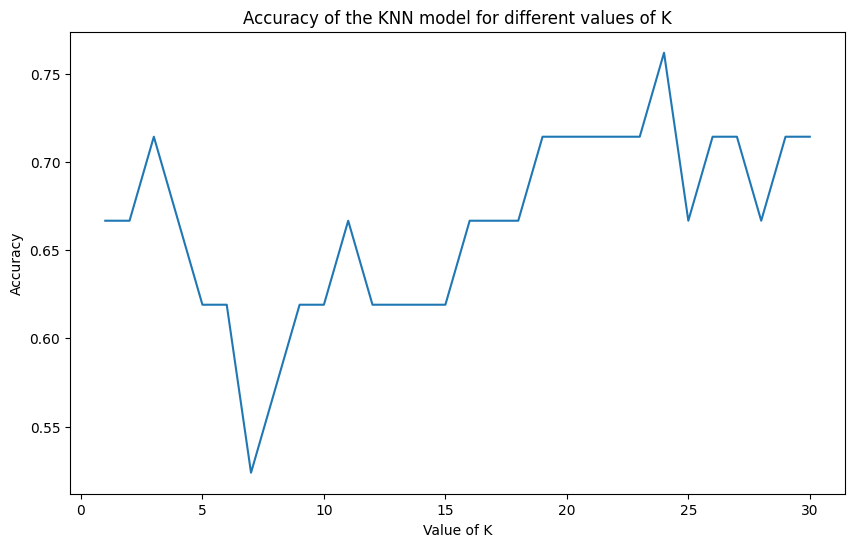

In [ ]:
# Graficar la precisión vs K
plt.figure(figsize=(10, 6))
plt.plot(k_range, scores)
plt.xlabel('Value of K')
plt.ylabel('Accuracy')
plt.title('Accuracy of the KNN model for different values of K')
plt.show()


In [ ]:
# Encontrar el K óptimo
k_optimo = k_range[scores.index(max(scores))]
print(f"El valor óptimo de K es: {k_optimo}")

El valor óptimo de K es: 24


In [ ]:
# Crear y entrenar el modelo KNN con el K óptimo
knn_optimo = KNeighborsClassifier(n_neighbors=k_optimo)
knn_optimo.fit(X_train_scaled, y_train)


KNeighborsClassifier(n_neighbors=24)

In [ ]:
# Hacer predicciones
y_pred = knn_optimo.predict(X_test_scaled)


In [ ]:
# Calcular la matriz de confusión
cm = confusion_matrix(y_test, y_pred)

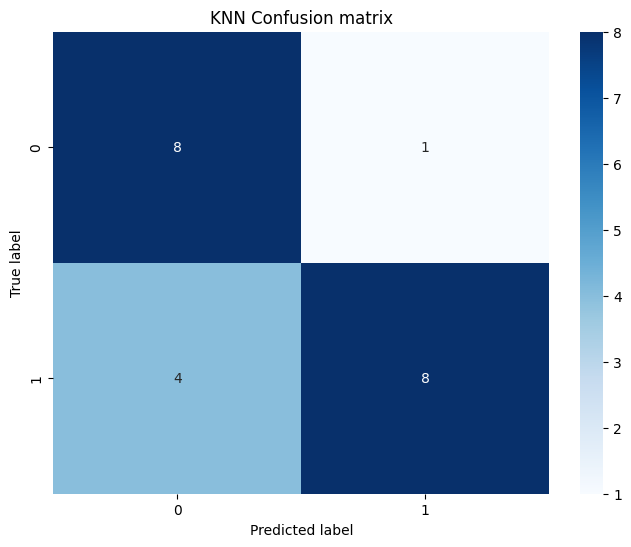

In [ ]:
# Graficar la matriz de confusión
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('KNN Confusion matrix')
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.show()

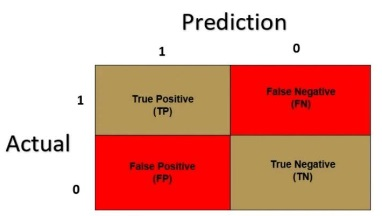

In [ ]:
tp=8
fp=4
fn=1
tn=8

In [ ]:
# Calcular accuracy y especificidad
accuracy = accuracy_score(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()
especificidad = tn / (tn + fp)

In [ ]:
print(f"Accuracy: {accuracy:.4f}")
print(f"Especificidad: {especificidad:.4f}")

Accuracy: 0.7619
Especificidad: 0.8889


In [ ]:
from sklearn.metrics import confusion_matrix

# Cálculo de P_o
P_o = (tp + tn) / (tp + tn + fp + fn)

# Cálculo de P_e
P_e = ((tp + fp) / (tp + tn + fp + fn)) * ((tp + fn) / (tp + tn + fp + fn)) + \
       ((tn + fn) / (tp + tn + fp + fn)) * ((tn + fp) / (tp + tn + fp + fn))

# Cálculo de Kappa
kappa = (P_o - P_e) / (1 - P_e)

print("Kappa:", kappa)

Kappa: 0.5333333333333332


In [ ]:
Precision = tp / (tp + fp)
Precision

np.float64(0.8888888888888888)

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score

# Calcular la precisión
precision = precision_score(y_test, y_pred)
print(f'Precisión: {precision:.2f}')

# Calcular el recall
recall = recall_score(y_test, y_pred)
print(f'Recall: {recall:.2f}')

# Calcular el F1 Score
f1 = f1_score(y_test, y_pred)
print(f'F1 Score: {f1:.2f}')

Precisión: 0.89
Recall: 0.67
F1 Score: 0.76


In [ ]:
# Realizar PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_train_scaled)

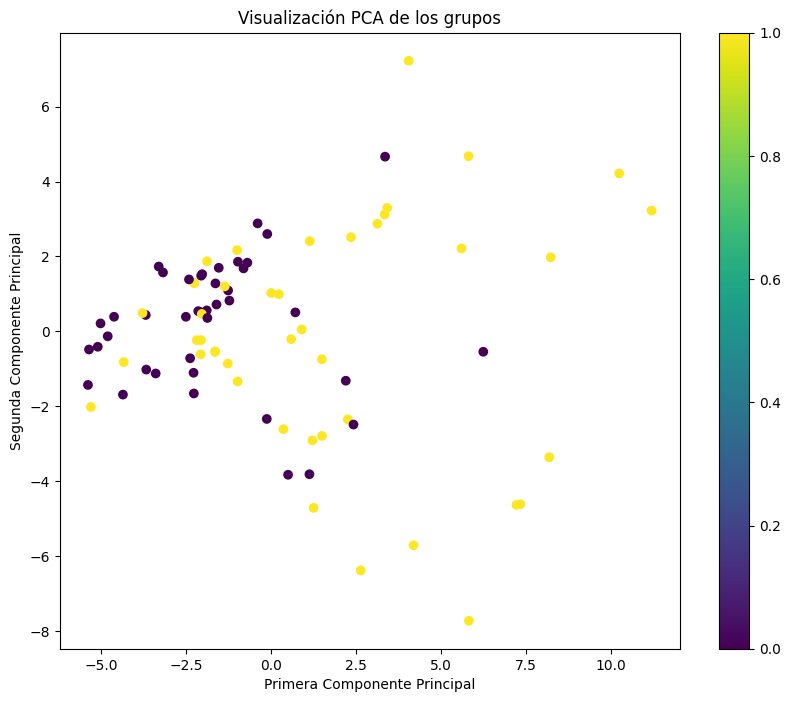

In [ ]:
# Graficar los resultados del PCA
plt.figure(figsize=(10, 8))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_train, cmap='viridis')
plt.colorbar(scatter)
plt.title('Visualización PCA de los grupos')
plt.xlabel('Primera Componente Principal')
plt.ylabel('Segunda Componente Principal')
plt.show()

In [ ]:
datos['Predicciones'] = knn_optimo.predict(scaler.transform(X))


In [ ]:
datos

,Name,SMILE,Total Molweight,Monoisotopic Mass,cLogP,cLogS,H-Acceptors,H-Donors,Total Surface Area,Relative PSA,...,Amides,Amines,Alkyl-Amines,Aromatic Amines,Aromatic Nitrogens,Basic Nitrogens,Acidic Oxygens,DataBase,Senotherapeutic,Predicciones
0,Ferric nitrilotriacetate,C(C(=O)[O-])N(CC(=O)[O-])CC(=O)[O-].[Fe+3],243.960,191.042989,-3.8594,0.868,7,3,137.38,0.59667,...,0,1,1,0,0,1,3,NoSenotherapeutic,0,0
1,Nitrilotriacetic acid,C(C(=O)O)N(CC(=O)O)CC(=O)O,191.138,191.042989,-3.8594,0.868,7,3,137.38,0.59667,...,0,1,1,0,0,1,3,NoSenotherapeutic,0,0
2,Oleuropein aglycone,C/C=C/1\[C@@H](C(=CO[C@H]1O)C(=O)OC)CC(=O)OCCC...,378.376,378.131470,1.5247,-2.068,8,3,284.53,0.33522,...,0,0,0,0,0,0,0,Senotherapeutic,1,1
3,Rapamycin,C[C@@H]1CC[C@H]2C[C@@H](/C(=C/C=C/C=C/[C@H](C[...,914.182,913.555144,6.5106,-6.713,14,3,716.91,0.22046,...,1,0,0,0,0,0,0,Senotherapeutic,1,1
4,KU-60019,C[C@@H]1CN(C[C@@H](O1)C)CC(=O)NC2=CC3=C(C=C2)S...,547.674,547.214092,4.2047,-5.834,8,1,403.09,0.22856,...,1,1,1,0,0,1,0,Senotherapeutic,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99,TICRYNAFEN,O=C(O)COc1ccc(C(=O)c2cccs2)c(Cl)c1Cl,331.175,329.952034,2.9282,-4.991,4,1,225.41,0.30850,...,0,0,0,0,0,0,1,NoSenotherapeutic,0,1
100,BENDAZAC,O=C(O)COc1nn(Cc2ccccc2)c2ccccc12,282.298,282.100443,1.8077,-2.992,5,1,217.20,0.24853,...,0,0,0,0,2,0,1,NoSenotherapeutic,0,1
101,EF-24 (curcumin analogue),O=C1/C(=C/c2ccccc2F)CNC/C1=C\c1ccccc1F,311.330,311.112170,3.7321,-4.193,2,1,238.37,0.10278,...,0,1,1,0,0,1,0,Senotherapeutic,1,0
102,Fisetin,O=c1c(O)c(-c2ccc(O)c(O)c2)oc2cc(O)ccc12,286.238,286.047740,1.8359,-2.787,6,4,195.59,0.38570,...,0,0,0,0,0,0,0,Senotherapeutic,1,1


In [ ]:
# Guardar los resultados
#datos.to_csv('resultados_KNN.csv', index=False)

In [ ]:
# Cargar la base de datos COCONUT
ctd_data = pd.read_csv("/content/drive/MyDrive/Doctorado_Santiago/Set de Datos 2/Objetivo 4/0_DATA/CTD_curado.csv")

In [ ]:
ctd_data.dropna(inplace=True)

In [ ]:
# Preprocesar los datos de COCONUT con las columnas de interes
columnas_interes = [5, 7, 8, 9, 10, 11, 12, 13, 14, 15, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51]
X_new = ctd_data.iloc[:, columnas_interes]

In [ ]:
ctd_data_scaled = scaler.transform(X_new)

In [ ]:
# Hacer predicciones utilizando el modelo KNN entrenado
ctd_data['Predicciones'] = knn_optimo.predict(ctd_data_scaled)

In [ ]:
# Si también quieres las probabilidades de predicción (opcional)
ctd_data['Probabilidad'] = knn_optimo.predict_proba(ctd_data_scaled)[:, 1]


In [ ]:
# Ver las predicciones para la base de datos CTD
print(ctd_data['Predicciones'])


0        1
1        1
2        1
3        1
4        0
        ..
54396    1
54397    1
54398    1
54399    1
54400    1
Name: Predicciones, Length: 54401, dtype: int64


In [ ]:
# Analizar los resultados
# Por ejemplo, puedes contar cuántos compuestos se predicen como activos o inactivos
print(ctd_data['Predicciones'].value_counts())

Predicciones
0    39830
1    14571
Name: count, dtype: int64


In [ ]:
# Guardar el DataFrame con las predicciones
#ctd_data.to_csv('ctd_knn_predicciones.csv', index=False)

In [ ]:
# Mostrar las primeras filas de los resultados
ctd_data.head()

,GeneSymbol,SMILES,ChemicalName,Interaction,InteractionActions,Total Molweight,Molweight,Monoisotopic Mass,cLogP,cLogS,...,Hetero-Aromatic Rings,Amides,Amines,Alkyl-Amines,Aromatic Amines,Aromatic Nitrogens,Basic Nitrogens,Acidic Oxygens,Predicciones,Probabilidad
0,AKT1,[B-]12(OC3C(C(OC3(O1)CO)CO)O)OC4C(C(OC4(O2)CO)...,calcium fructoborate,calcium fructoborate affects the expression of...,affects^expression,774.258,367.0900,367.104785,-5.2466,2.630,...,0,0,0,0,0,0,0,0,1,0.750
1,PTEN,[B-]12(OC3C(C(OC3(O1)CO)CO)O)OC4C(C(OC4(O2)CO)...,calcium fructoborate,calcium fructoborate results in increased expr...,increases^expression,774.258,367.0900,367.104785,-5.2466,2.630,...,0,0,0,0,0,0,0,0,1,0.750
2,EIF4EBP1,[B-]12(OC3C(C(OC3(O1)CO)CO)O)OC4C(C(OC4(O2)CO)...,calcium fructoborate,calcium fructoborate affects the expression of...,affects^expression,774.258,367.0900,367.104785,-5.2466,2.630,...,0,0,0,0,0,0,0,0,1,0.750
3,TSC2,[B-]12(OC3C(C(OC3(O1)CO)CO)O)OC4C(C(OC4(O2)CO)...,calcium fructoborate,calcium fructoborate results in increased expr...,increases^expression,774.258,367.0900,367.104785,-5.2466,2.630,...,0,0,0,0,0,0,0,0,1,0.750
4,TP53,[Be+2].[O-]S(=O)(=O)[O-],beryllium sulfate,beryllium sulfate promotes the reaction [TP53 ...,affects^binding|increases^reaction,105.074,98.0779,97.967380,-3.4103,1.524,...,0,0,0,0,0,0,0,2,0,0.375


In [ ]:
# Filtrar los compuestos predichos como activos
compuestos_activos = ctd_data[ctd_data['Predicciones'] == 1]

In [ ]:
compuestos_activos

,GeneSymbol,SMILES,ChemicalName,Interaction,InteractionActions,Total Molweight,Molweight,Monoisotopic Mass,cLogP,cLogS,...,Hetero-Aromatic Rings,Amides,Amines,Alkyl-Amines,Aromatic Amines,Aromatic Nitrogens,Basic Nitrogens,Acidic Oxygens,Predicciones,Probabilidad
0,AKT1,[B-]12(OC3C(C(OC3(O1)CO)CO)O)OC4C(C(OC4(O2)CO)...,calcium fructoborate,calcium fructoborate affects the expression of...,affects^expression,774.258,367.090,367.104785,-5.2466,2.630,...,0,0,0,0,0,0,0,0,1,0.750000
1,PTEN,[B-]12(OC3C(C(OC3(O1)CO)CO)O)OC4C(C(OC4(O2)CO)...,calcium fructoborate,calcium fructoborate results in increased expr...,increases^expression,774.258,367.090,367.104785,-5.2466,2.630,...,0,0,0,0,0,0,0,0,1,0.750000
2,EIF4EBP1,[B-]12(OC3C(C(OC3(O1)CO)CO)O)OC4C(C(OC4(O2)CO)...,calcium fructoborate,calcium fructoborate affects the expression of...,affects^expression,774.258,367.090,367.104785,-5.2466,2.630,...,0,0,0,0,0,0,0,0,1,0.750000
3,TSC2,[B-]12(OC3C(C(OC3(O1)CO)CO)O)OC4C(C(OC4(O2)CO)...,calcium fructoborate,calcium fructoborate results in increased expr...,increases^expression,774.258,367.090,367.104785,-5.2466,2.630,...,0,0,0,0,0,0,0,0,1,0.750000
64,AKT1,[CH2-]C1CCCCC1[CH2-].C1C(N(C2=C(N1)N=C(NC2=O)N...,Folfox protocol,Curcumin promotes the reaction [Folfox protoco...,decreases^activity|decreases^expression|decrea...,998.835,473.445,473.165898,-2.2121,-4.076,...,0,3,1,0,1,0,1,2,1,0.625000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
54396,RELA,S1[As]2S[As]3[As]1S[As]2S3,tetraarsenic tetrasulfide,tetraarsenic tetrasulfide results in decreased...,decreases^expression,427.952,427.952,427.574656,0.0000,-0.530,...,0,0,0,0,0,0,0,0,1,0.583333
54397,RELA,S1[As]2S[As]3[As]1S[As]2S3,tetraarsenic tetrasulfide,tetraarsenic tetrasulfide results in decreased...,decreases^expression,427.952,427.952,427.574656,0.0000,-0.530,...,0,0,0,0,0,0,0,0,1,0.583333
54398,MTOR,S1[As]2S[As]3[As]1S[As]2S3,tetraarsenic tetrasulfide,tetraarsenic tetrasulfide promotes the reactio...,decreases^expression|increases^reaction,427.952,427.952,427.574656,0.0000,-0.530,...,0,0,0,0,0,0,0,0,1,0.583333
54399,EIF4EBP1,S1[As]2S[As]3[As]1S[As]2S3,tetraarsenic tetrasulfide,tetraarsenic tetrasulfide promotes the reactio...,decreases^expression|increases^reaction,427.952,427.952,427.574656,0.0000,-0.530,...,0,0,0,0,0,0,0,0,1,0.583333


In [ ]:
# Guardar los resultados positivos en un archivo CSV
#compuestos_activos.to_csv('Positivos_Sen_KNN.csv', index=False)

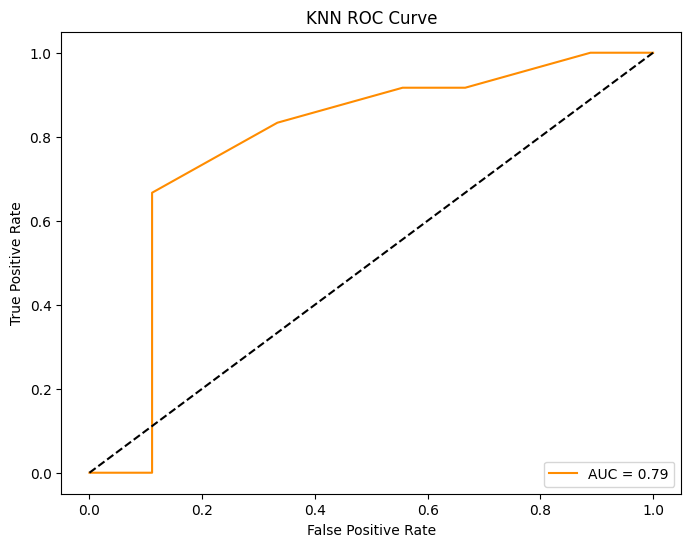

In [ ]:
# prompt:  curva ROC

import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

# Calcular las probabilidades de predicción
y_pred_proba = knn_optimo.predict_proba(X_test_scaled)[:, 1]

# Calcular la curva ROC
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

# Calcular el área bajo la curva ROC (AUC)
roc_auc = roc_auc_score(y_test, y_pred_proba)

# Graficar la curva ROC
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', label=f'AUC = {roc_auc:.2f}')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('KNN ROC Curve')
plt.legend(loc='lower right')
plt.show()
